In [4]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sb
import marimo as mo
import scipy.stats as st

from pathlib import Path

sys.path.insert(0, os.path.abspath("C:\\Users\\rhanes\\GitHub\\tyche\\src"))

import tyche as ty

In [5]:
saveresults = False

In [6]:
start_year_atb = 2010
end_year_atb = 2060
start_year_timeseries = 2022

In [7]:
designs = ty.Designs(
    path = '.',
    name = 'nuclear.xlsx' # nuclear-fixed.xlsx contains point estimate scenarios
)
investments = ty.Investments(
    path = '.',
    name = 'nuclear.xlsx'
)

designs.compile()

In [8]:
tranche_results = investments.evaluate_tranches(designs, sample_count=1000).metrics
#tranche_results.xs(1, level="Sample", drop_level=False)

[Text(0, 0, 'FOAK 6 Orders'),
 Text(1, 0, 'BOAK 2 of 6 Orders'),
 Text(2, 0, 'BOAK 3 of 6 Orders'),
 Text(3, 0, 'BOAK 4 of 6 Orders'),
 Text(4, 0, 'BOAK 5 of 6 Orders'),
 Text(5, 0, 'NOAK 6 Orders')]

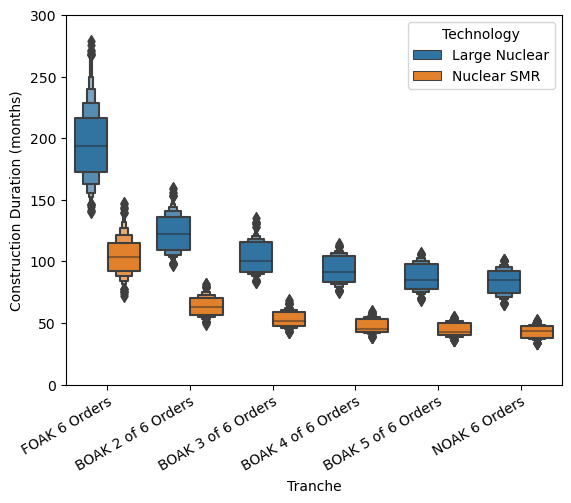

In [9]:
g = sb.boxenplot(
    x="Tranche",
    y="Value",
    hue="Technology",
    data=tranche_results.xs(
        "Construction Duration",
        level="Index"
    ).reset_index(
    )[["Technology", "Category", "Tranche", "Value"]],
    order=[
        "FOAK 6 Orders",
        "BOAK 2 of 6 Orders",
        "BOAK 3 of 6 Orders",
        "BOAK 4 of 6 Orders",
        "BOAK 5 of 6 Orders",
        "NOAK 6 Orders",
        ]
    )
g.set(ylabel="Construction Duration (months)",
     ylim=(0,300))
g.set_xticklabels(g.get_xticklabels(), rotation=30, ha='right', rotation_mode='anchor')
#g.legend()

[Text(0, 0, 'FOAK 6 Orders'),
 Text(1, 0, 'BOAK 2 of 6 Orders'),
 Text(2, 0, 'BOAK 3 of 6 Orders'),
 Text(3, 0, 'BOAK 4 of 6 Orders'),
 Text(4, 0, 'BOAK 5 of 6 Orders'),
 Text(5, 0, 'NOAK 6 Orders')]

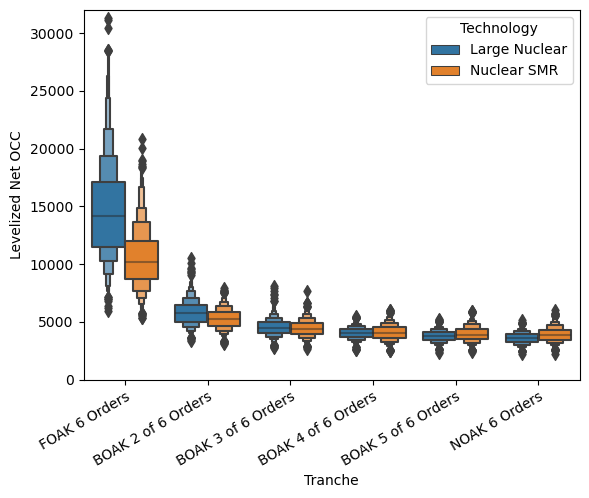

In [10]:
g = sb.boxenplot(
    x="Tranche",
    y="Value",
    hue="Technology",
    data=tranche_results.xs(
        "Levelized Net OCC",
        level="Index"
    ).reset_index(
    )[["Technology", "Category", "Tranche", "Value"]],
    order=[
        "FOAK 6 Orders",
        "BOAK 2 of 6 Orders",
        "BOAK 3 of 6 Orders",
        "BOAK 4 of 6 Orders",
        "BOAK 5 of 6 Orders",
        "NOAK 6 Orders",
        ]
    )
g.set(ylabel="Levelized Net OCC",
     ylim=(0,32000))
g.set_xticklabels(g.get_xticklabels(), rotation=30, ha='right', rotation_mode='anchor')
#g.legend()

[Text(0, 0, 'FOAK 3 Orders'),
 Text(1, 0, 'BOAK 3 Orders'),
 Text(2, 0, 'NOAK 3 Orders'),
 Text(3, 0, 'FOAK 6 Orders'),
 Text(4, 0, 'BOAK 6 Orders'),
 Text(5, 0, 'NOAK 6 Orders'),
 Text(6, 0, 'FOAK 13 Orders'),
 Text(7, 0, 'BOAK 13 Orders'),
 Text(8, 0, 'NOAK 13 Orders')]

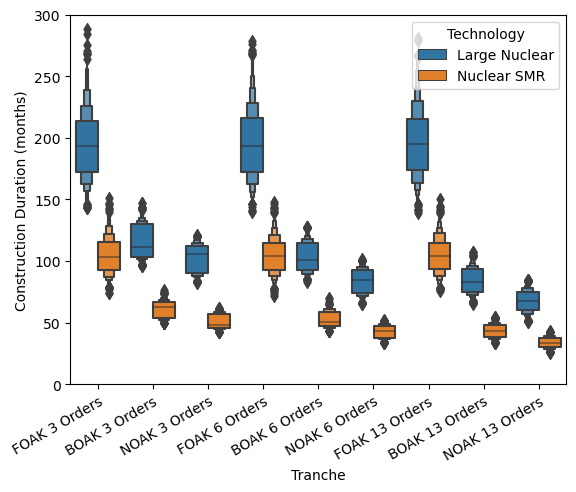

In [11]:
g = sb.boxenplot(
    x="Tranche",
    y="Value",
    hue="Technology",
    data=tranche_results.xs(
        "Construction Duration",
        level="Index"
    ).reset_index(
    )[["Technology", "Category", "Tranche", "Value"]],
    order=[
        "FOAK 3 Orders",
        "BOAK 3 Orders",
        "NOAK 3 Orders",
        "FOAK 6 Orders",
        "BOAK 6 Orders",
        "NOAK 6 Orders",
        "FOAK 13 Orders",
        "BOAK 13 Orders",
        "NOAK 13 Orders"
        ]
    )
g.set(ylabel="Construction Duration (months)",
     ylim=(0,300))
g.set_xticklabels(g.get_xticklabels(), rotation=30, ha='right', rotation_mode='anchor')
#g.legend()

[Text(0, 0, 'FOAK 3 Orders'),
 Text(1, 0, 'BOAK 3 Orders'),
 Text(2, 0, 'NOAK 3 Orders'),
 Text(3, 0, 'FOAK 6 Orders'),
 Text(4, 0, 'BOAK 6 Orders'),
 Text(5, 0, 'NOAK 6 Orders'),
 Text(6, 0, 'FOAK 13 Orders'),
 Text(7, 0, 'BOAK 13 Orders'),
 Text(8, 0, 'NOAK 13 Orders')]

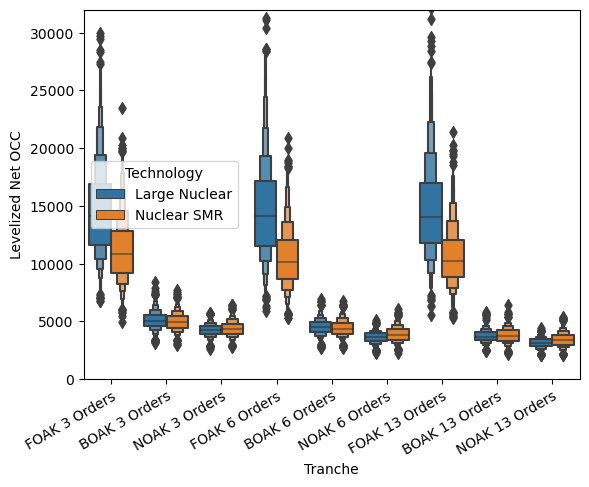

In [12]:
g = sb.boxenplot(
    x="Tranche",
    y="Value",
    hue="Technology",
    data=tranche_results.xs(
        "Levelized Net OCC",
        level="Index"
    ).reset_index(
    )[["Technology", "Category", "Tranche", "Value"]],
    order=[
        "FOAK 3 Orders",
        "BOAK 3 Orders",
        "NOAK 3 Orders",
        "FOAK 6 Orders",
        "BOAK 6 Orders",
        "NOAK 6 Orders",
        "FOAK 13 Orders",
        "BOAK 13 Orders",
        "NOAK 13 Orders"
        ]
    )
g.set(ylabel="Levelized Net OCC",
     ylim=(0,32000))
g.set_xticklabels(g.get_xticklabels(), rotation=30, ha='right', rotation_mode='anchor')
#g.legend()

In [13]:
tranches_timeseries = tranche_results.reset_index()

tranches_timeseries.drop(
    columns = ['Category','Units'],
    inplace = True
)

tranches_timeseries.rename(
    columns = {'Sample': 'sampl'},
    inplace = True
)

tranches_timeseries = tranches_timeseries[tranches_timeseries.Tranche.isin([
        "FOAK 6 Orders",
        "BOAK 2 of 6 Orders",
        "BOAK 3 of 6 Orders",
        "BOAK 4 of 6 Orders",
        "BOAK 5 of 6 Orders",
        "NOAK 6 Orders"
])]

tranches_timeseries = tranches_timeseries[tranches_timeseries.Index.isin([
    "Construction Duration",
    "Fixed Op and Maint",
    "Variable Op and Maint",
    "Levelized Net OCC"
])]

tranches_timeseries['plant'] = 1
tranches_timeseries.loc[tranches_timeseries.Tranche == 'BOAK 2 of 6 Orders','plant'] = 2
tranches_timeseries.loc[tranches_timeseries.Tranche == 'BOAK 3 of 6 Orders','plant'] = 3
tranches_timeseries.loc[tranches_timeseries.Tranche == 'BOAK 4 of 6 Orders','plant'] = 4
tranches_timeseries.loc[tranches_timeseries.Tranche == 'BOAK 5 of 6 Orders','plant'] = 5
tranches_timeseries.loc[tranches_timeseries.Tranche == 'NOAK 6 Orders','plant'] = 6

tranches_timeseries_occ = tranches_timeseries.loc[tranches_timeseries.Index == 'Levelized Net OCC', ['Technology','sampl','Value','plant']]
tranches_timeseries_duration = tranches_timeseries.loc[tranches_timeseries.Index == 'Construction Duration', ['Technology','sampl','Value','plant']]
tranches_timeseries_fom = tranches_timeseries.loc[tranches_timeseries.Index == 'Fixed Op and Maint', ['Technology','sampl','Value','plant']]
tranches_timeseries_vom = tranches_timeseries.loc[tranches_timeseries.Index == 'Variable Op and Maint', ['Technology','sampl','Value','plant']]

tranches_atb = tranches_timeseries_occ.merge(tranches_timeseries_duration,
                                             on = ['Technology','sampl','plant'],
                                             suffixes=('_occ', '_cons')
                                            ).merge(tranches_timeseries_fom,
                                                    on = ['Technology','sampl','plant']
                                                   ).merge(tranches_timeseries_vom,
                                                           on = ['Technology','sampl','plant'],
                                                           suffixes = ('_fom','_vom'))

tranches_atb.rename(
    columns = {'Value_occ': 'capcost',
              'Value_cons': 'cons_months',
              'Value_fom': 'fom',
              'Value_vom': 'vom'},
    inplace = True
)

tranches_atb['cons_years'] = np.ceil(tranches_atb.cons_months / 12)

tranches_atb['start_year'] = 0
tranches_atb['end_year'] = 0

tranches_atb.loc[tranches_atb.plant == 1, 'start_year'] = start_year_atb
tranches_atb.loc[tranches_atb.plant == 1, 'cons_years'] = (start_year_timeseries - start_year_atb) + tranches_atb.loc[tranches_atb.plant == 1, 'cons_years']
tranches_atb.loc[tranches_atb.plant == 1, 'end_year'] = start_year_atb + tranches_atb.loc[tranches_atb.plant == 1, 'cons_years']

for _s in tranches_atb.sampl.sort_values().unique():
    for _p in tranches_atb.plant.sort_values().unique():

        tranches_atb.loc[(tranches_atb.sampl == _s) & (tranches_atb.plant == _p), 'end_year'] = \
            tranches_atb.loc[(tranches_atb.sampl == _s) & (tranches_atb.plant == _p), 'start_year'].values[0] + \
            tranches_atb.loc[(tranches_atb.sampl == _s) & (tranches_atb.plant == _p), 'cons_years'].values[0] - 1
        
        if _p < tranches_atb.plant.max():
            tranches_atb.loc[(tranches_atb.sampl == _s) & (tranches_atb.plant == _p + 1), 'start_year'] = \
            tranches_atb.loc[(tranches_atb.sampl == _s) & (tranches_atb.plant == _p), 'end_year'].values[0] + 1

        if _p == tranches_atb.plant.max():
            tranches_atb.loc[(tranches_atb.sampl == _s) & (tranches_atb.plant == _p), 'end_year'] = end_year_atb + 1


# Sort first by technology, then sampl, then by plant number within sampl
tranches_atb = tranches_atb.sort_values(by = ['Technology','sampl','plant'])

tranches_atb['years'] = [np.arange(styr, enyr) for styr, enyr in zip(tranches_atb.start_year, tranches_atb.end_year)]

tranches_atb_timeseries = tranches_atb.explode(column = 'years')

if saveresults:
    tranches_atb_timeseries.to_csv('tranches-atb-withyears.csv',index=False)

In [14]:
tranches_atb_timeseries.loc[tranches_atb.sampl == 3]

,Technology,sampl,capcost,plant,cons_months,fom,vom,cons_years,start_year,end_year,years
8002,Large Nuclear,3,18774.990777,1,238.788083,195.206403,13.267670,32.0,2010,2041,2010
8002,Large Nuclear,3,18774.990777,1,238.788083,195.206403,13.267670,32.0,2010,2041,2011
8002,Large Nuclear,3,18774.990777,1,238.788083,195.206403,13.267670,32.0,2010,2041,2012
8002,Large Nuclear,3,18774.990777,1,238.788083,195.206403,13.267670,32.0,2010,2041,2013
8002,Large Nuclear,3,18774.990777,1,238.788083,195.206403,13.267670,32.0,2010,2041,2014
...,...,...,...,...,...,...,...,...,...,...,...
7002,Nuclear SMR,3,3723.319136,5,40.960412,194.454109,11.346009,4.0,2073,2080,2076
7002,Nuclear SMR,3,3723.319136,5,40.960412,194.454109,11.346009,4.0,2073,2080,2077
7002,Nuclear SMR,3,3723.319136,5,40.960412,194.454109,11.346009,4.0,2073,2080,2078
7002,Nuclear SMR,3,3723.319136,5,40.960412,194.454109,11.346009,4.0,2073,2080,2079


In [15]:
smr_atb_mod = pd.read_csv('nuclear-smr_ATB_2025_moderate.csv')
smr_atb_adv = pd.read_csv('nuclear-smr_ATB_2025_advanced.csv')
smr_atb_con = pd.read_csv('nuclear-smr_ATB_2025_conservative.csv')

In [16]:
lg_atb_mod = pd.read_csv('nuclear_ATB_2025_moderate.csv')
lg_atb_adv = pd.read_csv('nuclear_ATB_2025_advanced.csv')
lg_atb_con = pd.read_csv('nuclear_ATB_2025_conservative.csv')

In [61]:
smr_atb_mod.head()

,i,t,capcost,fom,vom,heatrate
0,Nuclear-SMR,2010,7937.174972,134.912177,3.556022,10.455
1,Nuclear-SMR,2011,7937.174972,134.912177,3.556022,10.455
2,Nuclear-SMR,2012,7937.174972,134.912177,3.556022,10.455
3,Nuclear-SMR,2013,7937.174972,134.912177,3.556022,10.455
4,Nuclear-SMR,2014,7937.174972,134.912177,3.556022,10.455


In [17]:
tranches_atb_timeseries.loc[(tranches_atb_timeseries.Technology == 'Nuclear SMR') &
    (tranches_atb_timeseries.years <= end_year_atb)].reset_index().head()

,index,Technology,sampl,capcost,plant,cons_months,fom,vom,cons_years,start_year,end_year,years
0,9000,Nuclear SMR,1,11472.722905,1,117.35403,171.502882,13.051741,22.0,2010,2035,2010
1,9000,Nuclear SMR,1,11472.722905,1,117.35403,171.502882,13.051741,22.0,2010,2035,2011
2,9000,Nuclear SMR,1,11472.722905,1,117.35403,171.502882,13.051741,22.0,2010,2035,2012
3,9000,Nuclear SMR,1,11472.722905,1,117.35403,171.502882,13.051741,22.0,2010,2035,2013
4,9000,Nuclear SMR,1,11472.722905,1,117.35403,171.502882,13.051741,22.0,2010,2035,2014


<AxesSubplot: xlabel='years', ylabel='capcost'>

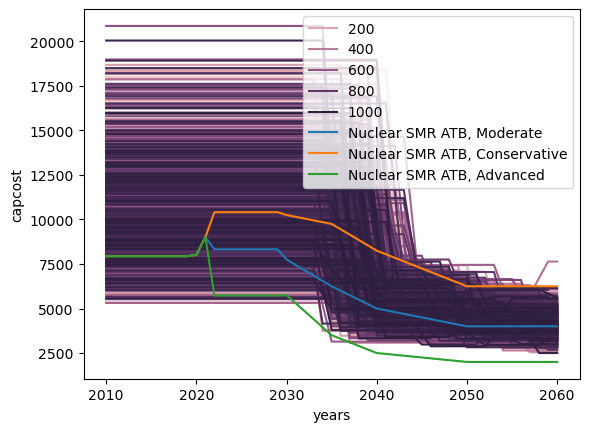

In [18]:
sb.lineplot(
    data = tranches_atb_timeseries.loc[(tranches_atb_timeseries.Technology == 'Nuclear SMR') &
    (tranches_atb_timeseries.years <= end_year_atb)].reset_index(),
    x = 'years',
    y = 'capcost',
    hue = 'sampl'
)

sb.lineplot(data = smr_atb_mod,
            x = 't',
            y = 'capcost',
            label = 'Nuclear SMR ATB, Moderate'
           )

sb.lineplot(data = smr_atb_con,
            x = 't',
            y = 'capcost',
            label = 'Nuclear SMR ATB, Conservative'
           )

sb.lineplot(data = smr_atb_adv,
            x = 't',
            y = 'capcost',
            label = 'Nuclear SMR ATB, Advanced'
           )



In [59]:
smr_ci_rawdata = tranches_atb_timeseries.loc[
    (tranches_atb_timeseries.Technology == 'Nuclear SMR') &
    (tranches_atb_timeseries.years <= end_year_atb)
    ].reset_index()[['years','capcost']]

smr_ci_lower_dict = {}
smr_ci_upper_dict = {}

for i in sorted(smr_ci_rawdata.years.unique()):
    _ci = st.bootstrap((smr_ci_rawdata.copy().loc[smr_ci_rawdata.years == i,'capcost'].values,),
                       np.mean,
                       axis=0,
                       confidence_level=0.90).confidence_interval
    smr_ci_lower_dict[i] = _ci[0]
    smr_ci_upper_dict[i] = _ci[1]

In [66]:
smr_ci_lower_df = pd.DataFrame.from_dict(smr_ci_lower_dict, orient='index').reset_index()
smr_ci_lower_df.rename(
    columns = {'index':'t',
               0: 'capcost'},
    inplace=True
)

if saveresults:
    smr_ci_lower_df.merge(smr_atb_con.loc[:,['i','t','fom','vom','heatrate']],
                          on='t',
                          how='outer'
                         ).to_csv('nuclear-smr-tyche-ci-lower.csv',index=False)

In [68]:
smr_ci_upper_df = pd.DataFrame.from_dict(smr_ci_upper_dict, orient='index').reset_index()
smr_ci_upper_df.rename(
    columns = {'index':'t',
               0: 'capcost'},
    inplace=True
)

if saveresults:
    smr_ci_upper_df.merge(smr_atb_adv.loc[:,['i','t','fom','vom','heatrate']],
                          on='t',
                          how='outer'
                         ).to_csv('nuclear-smr-tyche-ci-upper.csv',index=False)

In [69]:
lgnuc_ci_rawdata = tranches_atb_timeseries.loc[
    (tranches_atb_timeseries.Technology == 'Large Nuclear') &
    (tranches_atb_timeseries.years <= end_year_atb)
    ].reset_index()[['years','capcost']]

lgnuc_ci_lower_dict = {}
lgnuc_ci_upper_dict = {}

for i in sorted(lgnuc_ci_rawdata.years.unique()):
    _ci = st.bootstrap((lgnuc_ci_rawdata.copy().loc[lgnuc_ci_rawdata.years == i,'capcost'].values,),
                       np.mean,
                       axis=0,
                       confidence_level=0.90).confidence_interval
    lgnuc_ci_lower_dict[i] = _ci[0]
    lgnuc_ci_upper_dict[i] = _ci[1]

In [71]:
lgnuc_ci_lower_df = pd.DataFrame.from_dict(lgnuc_ci_lower_dict, orient='index').reset_index()
lgnuc_ci_lower_df.rename(
    columns = {'index':'t',
               0: 'capcost'},
    inplace=True
)

if saveresults:
    lgnuc_ci_lower_df.merge(lg_atb_con.loc[:,['i','t','fom','vom','heatrate']],
                          on='t',
                          how='outer'
                         ).to_csv('nuclear-large-tyche-ci-lower.csv',index=False)

In [72]:
lgnuc_ci_upper_df = pd.DataFrame.from_dict(lgnuc_ci_upper_dict, orient='index').reset_index()
lgnuc_ci_upper_df.rename(
    columns = {'index':'t',
               0: 'capcost'},
    inplace=True
)

if saveresults:
    lgnuc_ci_upper_df.merge(lg_atb_adv.loc[:,['i','t','fom','vom','heatrate']],
                          on='t',
                          how='outer'
                         ).to_csv('nuclear-large-tyche-ci-upper.csv',index=False)

<AxesSubplot: xlabel='years', ylabel='capcost'>

C:\Users\rhanes\AppData\Local\anaconda3\envs\tyche\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


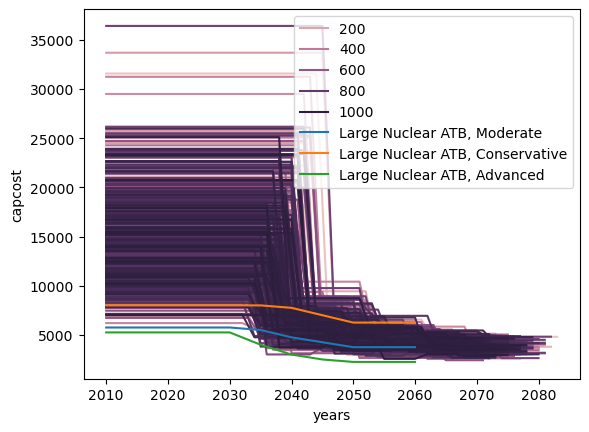

In [17]:
sb.lineplot(
    data = tranches_atb_timeseries.loc[(tranches_atb_timeseries.Technology == 'Large Nuclear') &
        (tranches_atb_timeseries.years <= end_year_atb)].reset_index(),
    x = 'years',
    y = 'capcost',
    hue = 'sampl'
)

sb.lineplot(data = lg_atb_mod,
            x = 't',
            y = 'capcost',
            label = 'Large Nuclear ATB, Moderate'
           )

sb.lineplot(data = lg_atb_con,
            x = 't',
            y = 'capcost',
            label = 'Large Nuclear ATB, Conservative'
           )

sb.lineplot(data = lg_atb_adv,
            x = 't',
            y = 'capcost',
            label = 'Large Nuclear ATB, Advanced'
           )

<AxesSubplot: xlabel='years', ylabel='capcost'>

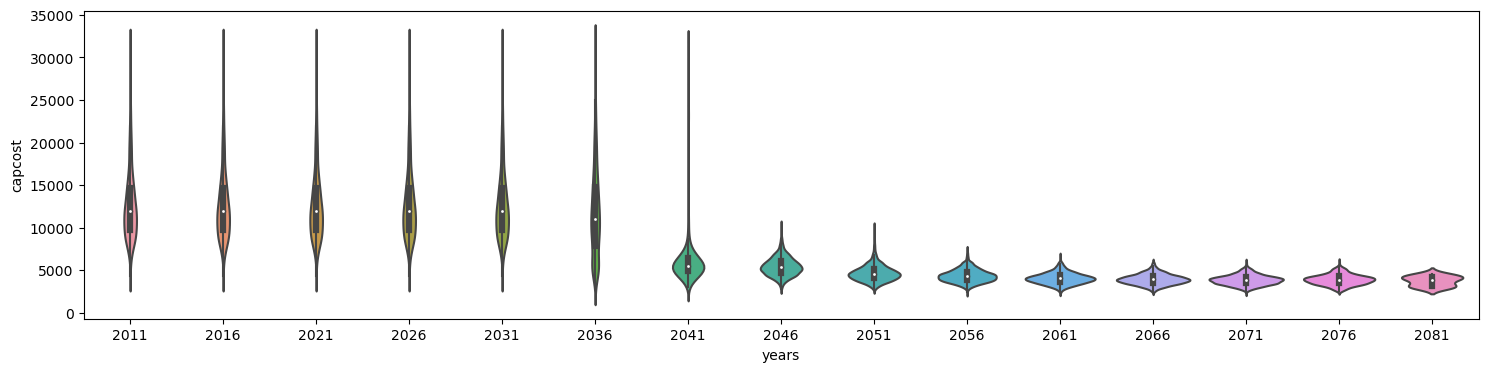

In [20]:
plt.figure(figsize=(18,4))

sb.violinplot(
    data = tranches_atb_timeseries.loc[tranches_atb_timeseries.years % 5 == 1],
    x = 'years',
    y = 'capcost',
    hue = None,
)

In [21]:
tranches_atb_timeseries.head()

,Technology,sampl,capcost,plant,cons_months,fom,vom,cons_years,start_year,end_year,years
8000,Large Nuclear,1,8718.453997,1,150.655604,189.314888,12.7221,25.0,2010,2034,2010
8000,Large Nuclear,1,8718.453997,1,150.655604,189.314888,12.7221,25.0,2010,2034,2011
8000,Large Nuclear,1,8718.453997,1,150.655604,189.314888,12.7221,25.0,2010,2034,2012
8000,Large Nuclear,1,8718.453997,1,150.655604,189.314888,12.7221,25.0,2010,2034,2013
8000,Large Nuclear,1,8718.453997,1,150.655604,189.314888,12.7221,25.0,2010,2034,2014


In [23]:
tranches_atb_timeseries_large = tranches_atb_timeseries.copy().loc[
    (tranches_atb_timeseries.Technology == 'Large Nuclear') &
    (tranches_atb_timeseries.years <= end_year_atb)]

In [22]:
tranches_atb_timeseries_smr = tranches_atb_timeseries.copy().loc[
    (tranches_atb_timeseries.Technology == 'Nuclear SMR') &
    (tranches_atb_timeseries.years <= end_year_atb)]

In [31]:
tranches_atb_timeseries_smr_median = tranches_atb_timeseries_smr.groupby('years').agg({'fom':'median','vom':'median','capcost':'median'}).reset_index()
if saveresults:
    tranches_atb_timeseries_smr_median.to_csv('nuclear-smr-tyche-50th.csv',index=False)

In [32]:
tranches_atb_timeseries_large_median = tranches_atb_timeseries_large.groupby('years').agg({'fom':'median','vom':'median','capcost':'median'}).reset_index()
if saveresults:
    tranches_atb_timeseries_large_median.to_csv('nuclear-large-tyche-50th.csv',index=False)

In [33]:
tranches_atb_timeseries_smr_min = tranches_atb_timeseries_smr.groupby('years').agg({'fom':'min','vom':'min','capcost':'min'}).reset_index()
if saveresults:
    tranches_atb_timeseries_smr_min.to_csv('nuclear-smr-tyche-0th.csv',index=False)

In [34]:
tranches_atb_timeseries_large_min = tranches_atb_timeseries_large.groupby('years').agg({'fom':'min','vom':'min','capcost':'min'}).reset_index()
if saveresults:
    tranches_atb_timeseries_large_min.to_csv('nuclear-large-tyche-0th.csv',index=False)

In [35]:
tranches_atb_timeseries_smr_max = tranches_atb_timeseries_smr.groupby('years').agg({'fom':'max','vom':'max','capcost':'max'}).reset_index()
if saveresults:
    tranches_atb_timeseries_smr_max.to_csv('nuclear-smr-tyche-100th.csv',index=False)

In [36]:
tranches_atb_timeseries_large_max = tranches_atb_timeseries_large.groupby('years').agg({'fom':'max','vom':'max','capcost':'max'}).reset_index()
if saveresults:
    tranches_atb_timeseries_large_max.to_csv('nuclear-large-tyche-100th.csv',index=False)